# Eb, Mono and DCs

In [1]:
# Library import
library(Seurat)
library(ggplot2)
library(sctransform)
library(harmony)
library(patchwork)
library(dplyr)
library(magrittr)
library(magrittr)
library(S4Vectors)
library(SingleCellExperiment)
library(slingshot)
library(tradeSeq)

BiocParallel::register(BiocParallel::SerialParam())
# Define a color pallete to use
pal <- c(RColorBrewer::brewer.pal(9, "Set1"), RColorBrewer::brewer.pal(8, "Set2"))

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following object is masked from ‘package:sctransform’:

    generate


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:dplyr’:

    combine


The following objects are masked from ‘package

In [2]:
# Multicore CPU usage activation - Future

library(future)

# plan("multicore", workers = 24) # Mac Pro 6.1
# plan(workers = 36) # iMac Pro 1.1
# plan("multicore", workers = 8) # 4 core Intel CPU and M1 have 8 threads
# plan("multicore", workers = 12) # 6 core Intel CPU has 12 threads
plan("multicore", workers = 10) # 10 core M1 Pro CPU has 10 threads

# Set RAM Size to 3/4 of total RAM

# options(future.globals.maxSize = 48000 * 1024^2) # Mac Pros have 64 Gb
options(future.globals.maxSize = 16000 * 1024^2) # iMacs and MacBook Pros have 16 Gb

future.seed = TRUE # Removes future-generated statistical errors

# Eb

In [3]:
# Read Seurat

Multimodal_seurat <- readRDS('Seurat.rds')
Multimodal_seurat

# Create Eb object containing only Erythroid cells
Eb <- subset(Multimodal_seurat, subset = CellType == "Erythroid cells")
Eb

An object of class Seurat 
773 features across 22061 samples within 3 assays 
Active assay: ADT (37 features, 37 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, SCT
 3 dimensional reductions calculated: pca, apca, wnn.umap

An object of class Seurat 
773 features across 13902 samples within 3 assays 
Active assay: ADT (37 features, 37 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, SCT
 3 dimensional reductions calculated: pca, apca, wnn.umap

In [1]:
Eb <- readRDS("Eb.rds")

In [4]:
# Extract the wnnUMAP coordinates
wnn_coords <- FetchData(Eb, vars = c("wnnUMAP_1", "wnnUMAP_2"))

# Identify cells that meet both coordinate criteria
cells_to_keep <- rownames(wnn_coords[wnn_coords$wnnUMAP_1 > -2 & wnn_coords$wnnUMAP_2 > -4.8, ])

# Subset the Seurat object
Eb <- subset(Eb, cells = cells_to_keep)

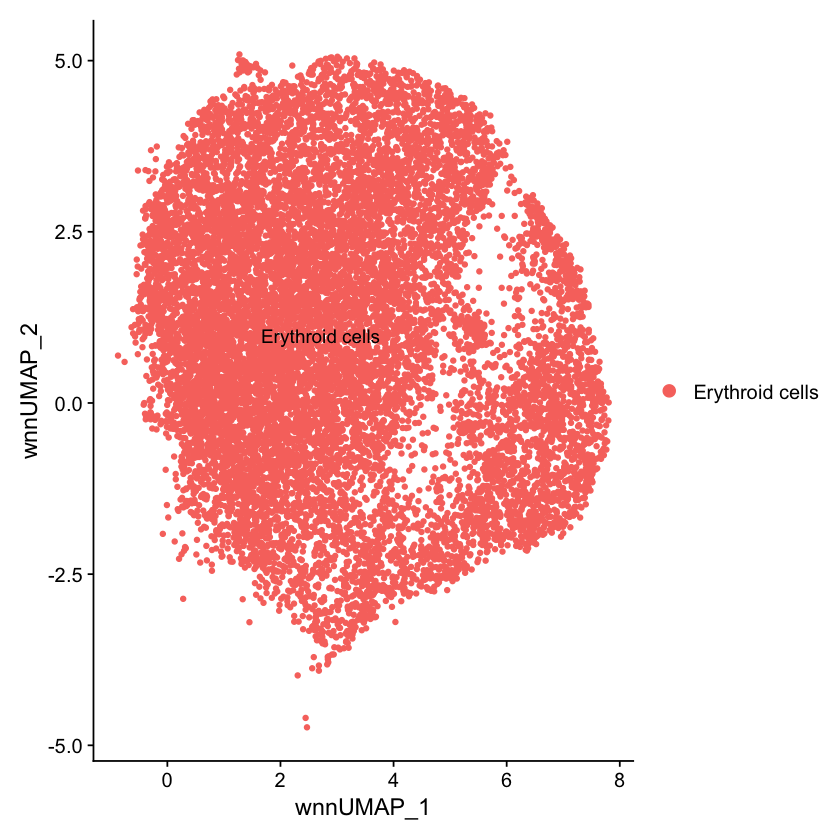

In [5]:
DimPlot(Eb, reduction = "wnn.umap", pt.size = 1, label = TRUE,  group.by = "CellType") + 
  ggtitle(NULL)
ggsave("eb_dimplot_celltype.jpeg", plot = last_plot(), device = "jpeg", dpi = 600, width = 10.85, height = 9)

In [13]:
DefaultAssay(Eb) <- "SCT"

fp <- FeaturePlot(
  object = Eb, 
  features = "ARG1", 
  reduction = "wnn.umap", 
  pt.size = 0.5
) + 
  xlim(-2.4, 9.6)

ggsave(
  filename = "eb_arg1.jpeg", 
  plot = fp, 
  device = "jpeg", 
  dpi = 600, 
  width = 7.3, 
  height = 7
)


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (e8278141f3d2a0abfc1356264ada7861-4); on e8278141f3d2a0abfc1356264ada7861@MacBook-Pro-Roman.local<99980>]”
Warning message:
“Adding a command log without an assay associated with it”



   0    3    4    6    7    8 
8940 2089 1878  440  325  215 

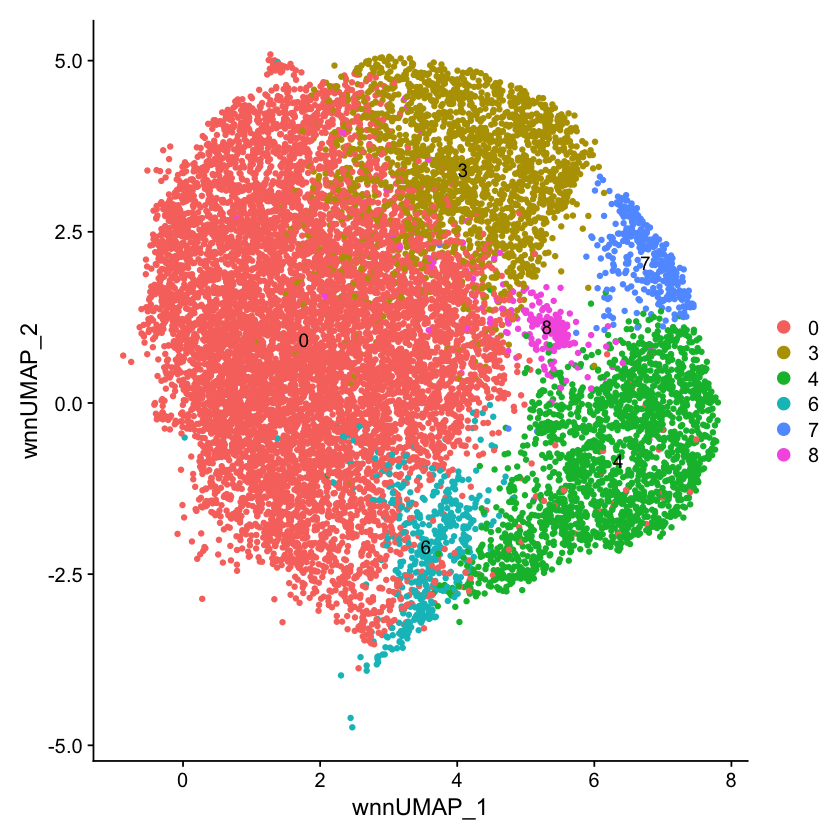

In [19]:
Eb <- FindClusters(Eb, graph.name = "wsnn", algorithm = 3,
                    resolution = 0.5, verbose = FALSE)

Idents(Eb) <- "seurat_clusters"

Eb <- RenameIdents(
  Eb,
  `1` = "0",
  `15`  = "0",
  `2`  = "0",
  `10`  = "0",
  `14`  = "0",
  `12`  = "0",
  `13` = "0",
  `11`  = "0",
  `17`  = "0",
  `16`  = "0",
  `5`  = "0",
  `9`  = "0"
)

Eb$seurat_clusters <- Idents(Eb)

table(Idents(Eb))

DimPlot(Eb, reduction = "wnn.umap", pt.size = 1, label = TRUE,  group.by = "seurat_clusters") + 
  ggtitle(NULL)
ggsave("eb_dimplot_celltype.jpeg", plot = last_plot(), device = "jpeg", dpi = 600, width = 10.8, height = 9)

In [20]:
library(patchwork)
library(viridis)
library(ggplot2)

new_ids <- c(
  "6" = "CFU-E",
  "0" = "Pro Eb",
  "4" = "Baso Eb",
  "3" = "Poly Eb",
  "7" = "Ortho Eb",
  "8" = "ARG1+ Ortho Eb"
)

# Rename the identities
Eb <- RenameIdents(Eb, new_ids)

# Define target order
cell_order <- c(
  "CFU-E", 
  "Pro Eb", 
  "Baso Eb", 
  "Poly Eb",
  "Ortho Eb", 
  "ARG1+ Ortho Eb"
)

# Filter order to only keep levels actually present in the object to prevent NA groups
actual_levels <- intersect(cell_order, unique(as.character(Idents(Eb))))

# Relevel Idents cleanly
Idents(Eb) <- factor(as.character(Idents(Eb)), levels = actual_levels)

# Store back into metadata (removing any unmapped NA cells for plotting if necessary)
Eb$CellType <- Idents(Eb)

# Remove NA cells if any original clusters were excluded during renaming
Eb <- subset(Eb, subset = CellType %in% actual_levels)

table(Eb$CellType)


         CFU-E         Pro Eb        Baso Eb        Poly Eb       Ortho Eb 
           440           8940           1878           2089            325 
ARG1+ Ortho Eb 
           215 

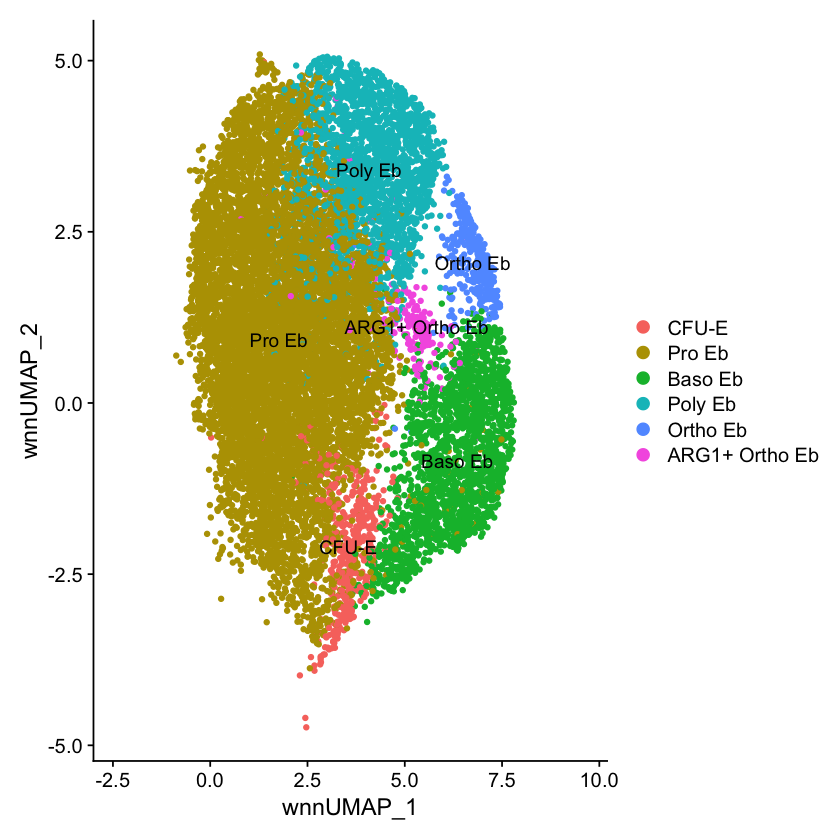

In [12]:
DimPlot(Eb, reduction = "wnn.umap", pt.size = 1, label = TRUE,  group.by = "CellType") + 
  ggtitle(NULL) + 
  xlim(-2.4, 9.6)
ggsave("eb_dimplot_celltype.jpeg", plot = last_plot(), device = "jpeg", dpi = 600, width = 10.8, height = 9)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


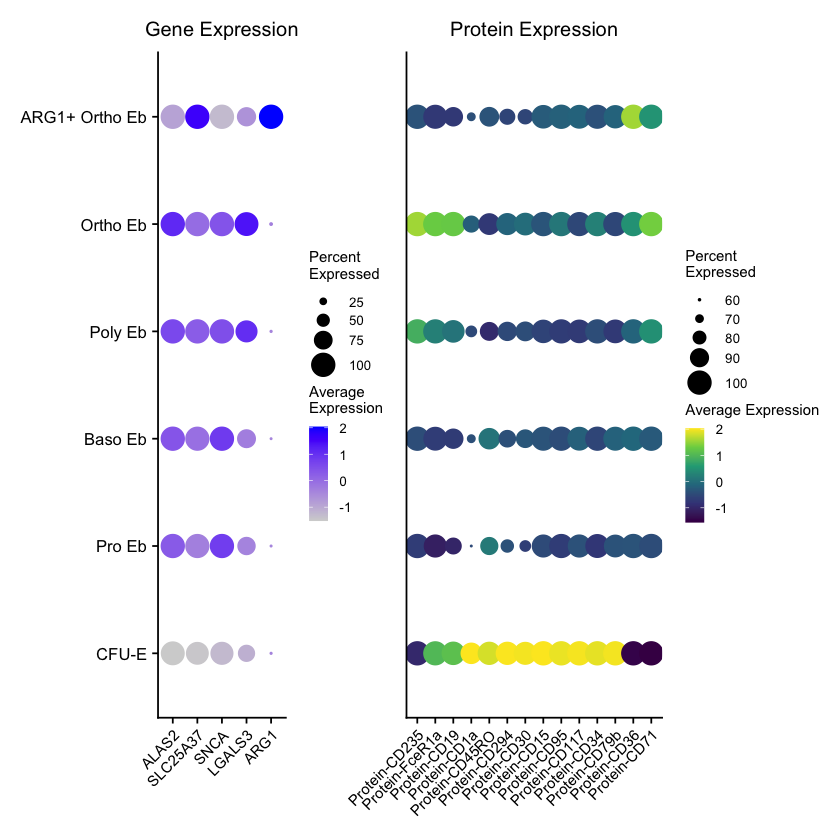

In [4]:
library(patchwork)
library(viridis)
library(ggplot2)

sct_markers <- unique(c("ALAS2", "SLC25A37", "SNCA", "LGALS3", "ARG1"))

adt_markers <- unique(c(
  "Protein-CD235", "Protein-CD71", "Protein-CD36",
  "Protein-CD34", "Protein-CD117", "Protein-CD45RO", 
  "Protein-CD30", "Protein-FceR1a", "Protein-CD294",
  "Protein-CD1a", "Protein-CD15", "Protein-CD95",
  "Protein-CD19", "Protein-CD79b"
))


adt_avg <- AverageExpression(
  Eb, 
  features = adt_markers, 
  assays = "ADT", 
  group.by = "CellType", 
  layer = "data"
)$ADT

# Calculate distance matrix and perform hierarchical clustering across ADTs (rows)
adt_dist <- dist(adt_avg)
adt_hc <- hclust(adt_dist, method = "complete")

# Extract the reordered ADT markers from the dendrogram leaves
adt_markers_clustered <- rownames(adt_avg)[adt_hc$order]

p_sct <- DotPlot(
  Eb, 
  features = sct_markers, 
  assay = "SCT", 
  group.by = "CellType"
) + 
  RotatedAxis() + 
  ggtitle("Gene Expression") +
  guides(
    size = guide_legend(order = 1, title = "Percent\nExpressed"),
    color = guide_colorbar(order = 2, title = "Average\nExpression")
  ) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "plain", size = 12),
    axis.title.y = element_blank(),
    axis.title.x = element_blank(),
    axis.text.y = element_text(size = 10, face = "plain"),
    axis.text.x = element_text(size = 9, face = "plain"),
    legend.title = element_text(size = 9, face = "plain"),
    legend.text = element_text(size = 8, face = "plain"),
    legend.key.size = unit(0.4, "cm")
  )


p_adt <- DotPlot(
  Eb, 
  features = adt_markers_clustered, 
  assay = "ADT", 
  group.by = "CellType"
) + 
  scale_color_viridis_c(guide = guide_colorbar(order = 4, title = "Avg\nExpression")) +
  RotatedAxis() + 
  ggtitle("Protein Expression") +
  guides(
    size = guide_legend(order = 3, title = "Percent\nExpressed")
  ) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "plain", size = 12),
    axis.title.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.title.x = element_blank(),
    axis.text.x = element_text(size = 9, face = "plain"),
    legend.title = element_text(size = 9, face = "plain"),
    legend.text = element_text(size = 8, face = "plain"),
    legend.key.size = unit(0.4, "cm")
  )

multimodal_dotplot <- (p_sct + p_adt) + 
  plot_layout(widths = c(0.6, 1.2), guides = "keep") & 
  theme(
    legend.box = "vertical",
    legend.margin = margin(0, 0, 0, 0),
    legend.spacing.y = unit(0.1, "cm")
  )

multimodal_dotplot

ggsave(
  "eb_multimodal_dotplot.jpeg", 
  plot = multimodal_dotplot, 
  device = "jpeg", 
  dpi = 600, 
  width = 12, 
  height = 4.2
)

In [5]:
head(Eb@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,SampleTag,Sample,Donor,nCount_SCT,nFeature_SCT,RNA.weight,ADT.weight,wsnn_res.0.3,seurat_clusters,CellType,wsnn_res.0.5,CellType_Sample
,<fct>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<fct>,<dbl>,<int>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
11580,CordBlood,54,5,3694,35,SampleTag01_hs,Cord_Blood_1,Cord_Blood_1,93,10,1.588234e-01,0.8411766,3,4,Baso Eb,4,Baso Eb_Cord_Blood_1
18278,CordBlood,300,7,62435,37,SampleTag04_hs,Cord_Blood_4,Cord_Blood_4,92,10,2.654853e-13,1.0000000,1,6,CFU-E,6,CFU-E_Cord_Blood_4
32049,CordBlood,203,5,7066,37,SampleTag03_hs,Cord_Blood_3,Cord_Blood_3,94,8,3.422816e-07,0.9999997,1,0,Pro Eb,1,Pro Eb_Cord_Blood_3
38184,CordBlood,410,9,37170,36,SampleTag04_hs,Cord_Blood_4,Cord_Blood_4,91,8,3.773316e-01,0.6226684,0,3,Poly Eb,3,Poly Eb_Cord_Blood_4
42175,CordBlood,82,5,4455,35,SampleTag01_hs,Cord_Blood_1,Cord_Blood_1,94,12,5.025609e-01,0.4974391,0,0,Pro Eb,0,Pro Eb_Cord_Blood_1
43117,CordBlood,53,5,2912,28,SampleTag01_hs,Cord_Blood_1,Cord_Blood_1,94,10,1.264779e-01,0.8735221,0,0,Pro Eb,2,Pro Eb_Cord_Blood_1


In [6]:
# 2. Define ordered cluster levels
cell_order <- c(
  "CFU-E", 
  "Pro Eb", 
  "Baso Eb", 
  "Poly Eb",
  "Ortho Eb", 
  "ARG1+ Ortho Eb"
)

# 3. Get unique samples and construct ordered factor levels (Cluster -> Sample)
sample_order <- sort(unique(Eb$Sample))

combined_levels <- unlist(lapply(cell_order, function(cell) {
  paste(cell, sample_order, sep = "_" )
}))

# 4. Create ordered metadata column
Eb$CellType_Sample <- factor(
  paste(Eb$CellType, Eb$Sample, sep = "_" ),
  levels = combined_levels
)

# 5. Generate plot with Viridis colormap
p <- DotPlot(
  object = Eb,
  features = adt_markers_clustered,
  group.by = "CellType_Sample",
  assay = "ADT"
) +
  scale_color_viridis_c() +
  RotatedAxis() + 
  coord_flip() +
  labs(
    x = "ADT Markers",
    y = "Cluster / Sample"
  )

# 6. Save figure
ggsave(
  "eb_per_sample_adt_dotplot.jpeg", 
  plot = p, 
  device = "jpeg", 
  dpi = 600, 
  width = 15, 
  height = 7
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


In [11]:
library(Seurat)
library(pheatmap)
library(viridis)
library(scales)
library(RColorBrewer)

# Note: adt_markers_clustered is expected to be defined in your environment

# 1. Define ordered cluster and sample levels
cell_order <- c(
  "CFU-E", 
  "Pro Eb", 
  "Baso Eb", 
  "Poly Eb",
  "Ortho Eb", 
  "ARG1+ Ortho Eb"
)

sample_order <- sort(unique(Eb$Sample))

# Construct target group levels in exact sequence
target_levels <- unlist(lapply(cell_order, function(cell) {
  paste(cell, sample_order, sep = "_" )
}))

# 2. Update metadata in Seurat object
Eb$CellType_Sample <- factor(
  paste(Eb$CellType, Eb$Sample, sep = "_" ),
  levels = target_levels
)

# 3. Calculate Average Expression
avg_exp <- AverageExpression(
  Eb,
  assays = "ADT",
  group.by = "CellType_Sample",
  layer = "data"
)$ADT

# 4. Handle Seurat's underscore-to-dash conversion safely
seurat_converted_levels <- gsub("_", "-", target_levels)
matched_cols <- seurat_converted_levels[seurat_converted_levels %in% colnames(avg_exp)]

adt_features <- adt_markers_clustered[adt_markers_clustered %in% rownames(avg_exp)]

if (length(adt_features) == 0) {
  stop("None of the specified ADT markers were found in rownames(Eb[['ADT']]). Check feature names.")
}

mat <- avg_exp[adt_features, matched_cols, drop = FALSE]

# Restore original target level names for matrix keys
clean_colnames <- target_levels[match(matched_cols, seurat_converted_levels)]
colnames(mat) <- clean_colnames

# 5. Z-score scale, replace NaNs, and cap Z-scores symmetrically at [-2, +2]
mat_scaled <- t(scale(t(mat)))
mat_scaled[is.na(mat_scaled)] <- 0
mat_scaled[mat_scaled > 2]  <- 2
mat_scaled[mat_scaled < -2] <- -2

# 6. Robust annotation matching
grid_df <- expand.grid(Sample = sample_order, CellType = cell_order, stringsAsFactors = FALSE)
grid_df$Key <- paste(grid_df$CellType, grid_df$Sample, sep = "_")
grid_df <- grid_df[match(colnames(mat), grid_df$Key), ]

anno_col <- data.frame(
  CellType = factor(grid_df$CellType, levels = cell_order),
  Sample   = factor(grid_df$Sample, levels = sample_order),
  row.names = colnames(mat)
)

# 7. Map annotation color palettes explicitly
cell_colors <- scales::hue_pal()(length(cell_order))
names(cell_colors) <- cell_order

samp_n <- length(sample_order)
if (samp_n <= 8) {
  samp_colors <- RColorBrewer::brewer.pal(max(3, samp_n), "Dark2")[1:samp_n]
} else {
  samp_colors <- colorRampPalette(RColorBrewer::brewer.pal(8, "Dark2"))(samp_n)
}
names(samp_colors) <- sample_order

anno_colors <- list(
  CellType = cell_colors,
  Sample   = samp_colors
)

# 8. Define symmetric colorbar breaks around 0
min_z <- -2
max_z <- 2
legend_ticks <- seq(min_z, max_z, by = 1)
color_breaks <- seq(min_z, max_z, length.out = 257) # 257 break points = 256 color bins

# 9. Define color palette dynamically matched to color_breaks length (256 colors)
bwr <- colorRampPalette(c("blue", "white", "red"))(length(color_breaks) - 1)

# 10. Clean x-axis display labels (replace underscores with spaces)
display_colnames <- gsub("_", " ", colnames(mat))

# 11. Plot and save via pheatmap
pheatmap(
  mat = mat_scaled,
  color = bwr,       
  breaks = color_breaks,
  legend_breaks = legend_ticks,
  border_color = "white",               # Removes default grey borders around legend/cells
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  annotation_col = anno_col,
  annotation_colors = anno_colors,
  labels_col = display_colnames,
  cellwidth = 15,
  cellheight = 15,
  show_colnames = TRUE,
  show_rownames = TRUE,
  main = "ADT Expression by Cell Type and Sample",
  filename = "eb_per_sample_adt_heatmap.jpeg"
)

In [24]:
saveRDS(Eb, file = "Eb.rds")

# Monocytes-DCs axis

In [49]:
# Read Seurat object
Multimodal_seurat <- readRDS('Seurat.rds')
Multimodal_seurat

# Create object containing both Dendritic cells and Monocytes
obj <- subset(Multimodal_seurat, subset = CellType %in% c("Dendritic cells", "Monocytes"))
obj

An object of class Seurat 
773 features across 22061 samples within 3 assays 
Active assay: ADT (37 features, 37 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, SCT
 3 dimensional reductions calculated: pca, apca, wnn.umap

An object of class Seurat 
773 features across 1477 samples within 3 assays 
Active assay: ADT (37 features, 37 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, SCT
 3 dimensional reductions calculated: pca, apca, wnn.umap

In [50]:
wnn_coords <- FetchData(obj, vars = c("wnnUMAP_1", "wnnUMAP_2"))

# Identify cells that meet both coordinate criteria
cells_to_keep <- rownames(wnn_coords[wnn_coords$wnnUMAP_1 > -2 & wnn_coords$wnnUMAP_1 < 5, ])

# Subset the Seurat object
obj <- subset(obj, cells = cells_to_keep)

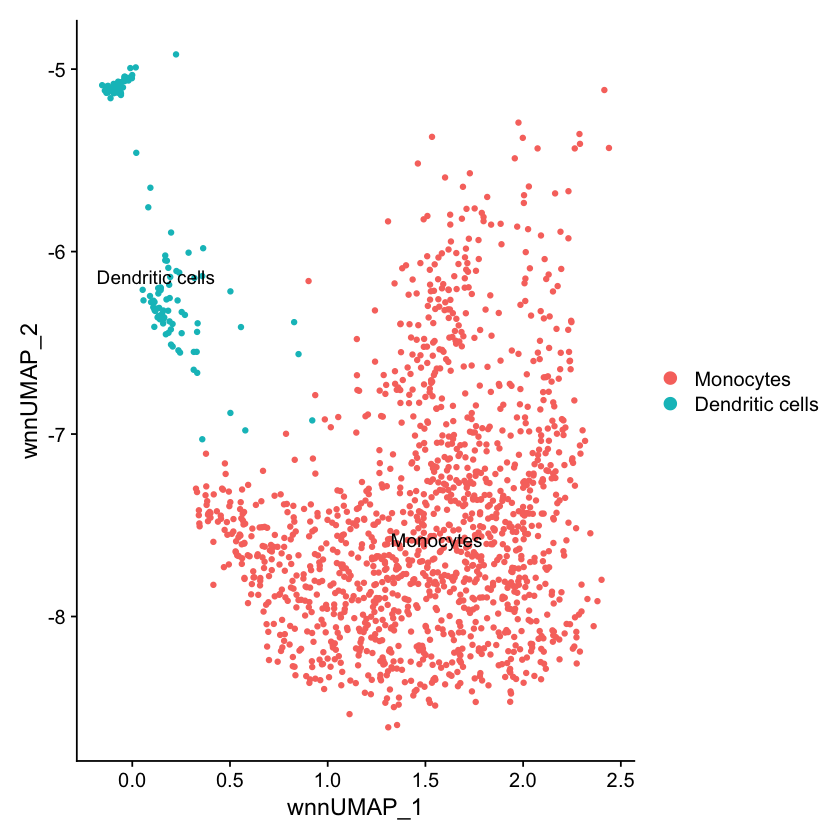

In [51]:
DimPlot(obj, reduction = "wnn.umap", pt.size = 1, label = TRUE,  group.by = "CellType") + 
  ggtitle(NULL)
ggsave("mono_dc_dimplot_celltype.jpeg", plot = last_plot(), device = "jpeg", dpi = 600, width = 10.85, height = 9)

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (5e75cf4e094067c87620536b823295d8-5); on 5e75cf4e094067c87620536b823295d8@MacBook-Pro-Roman.local<4345>]”
Warning message:
“Adding a command log without an assay associated with it”



  0   1   2   3   4   5   6 
562 345 204 146  95  71  50 

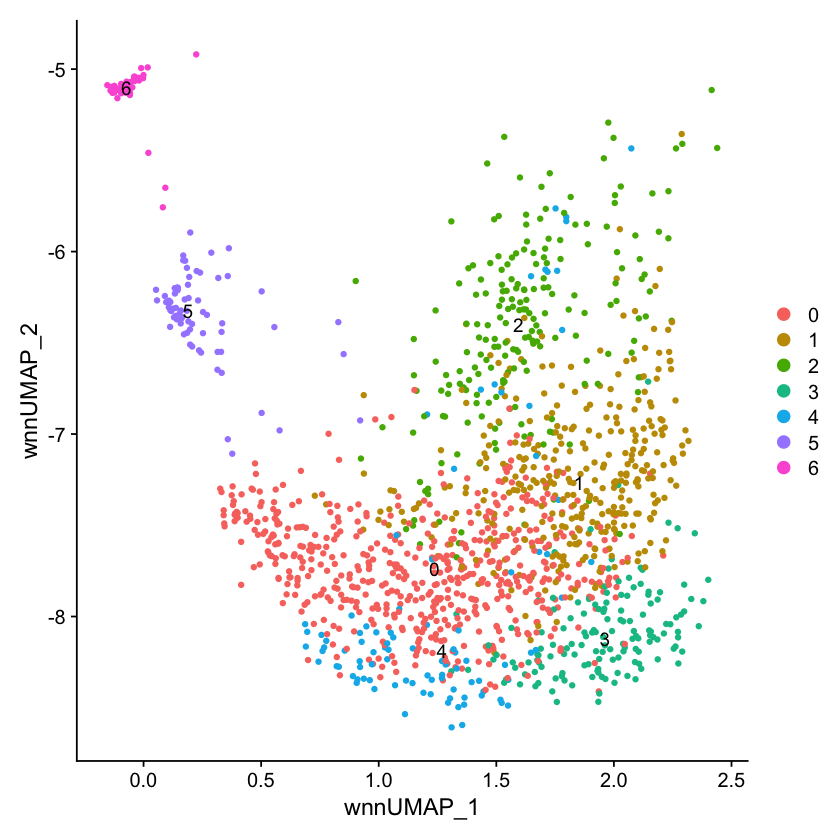

In [52]:
obj <- FindClusters(obj, graph.name = "wsnn", algorithm = 3,
                    resolution = 0.5, verbose = FALSE)

table(Idents(obj))

DimPlot(obj, reduction = "wnn.umap", pt.size = 1, label = TRUE,  group.by = "seurat_clusters") + 
  ggtitle(NULL)
ggsave("mono_dc_dimplot_celltype.jpeg", plot = last_plot(), device = "jpeg", dpi = 600, width = 10.8, height = 9)

In [53]:
DefaultAssay(obj) <- "SCT"

sct_counts <- LayerData(
  obj,
  assay = "SCT",
  layer = "counts"
)

gene_pct <- Matrix::rowMeans(sct_counts > 0)

keep_genes <- names(gene_pct[gene_pct >= 0.05])

keep_genes <- intersect(
  keep_genes,
  rownames(sct_counts)
)

counts <- as.matrix(
  sct_counts[keep_genes, , drop = FALSE]
)

dimred <- obj@reductions$wnn.umap@cell.embeddings
clustering <- obj@meta.data$seurat_clusters

set.seed(1)

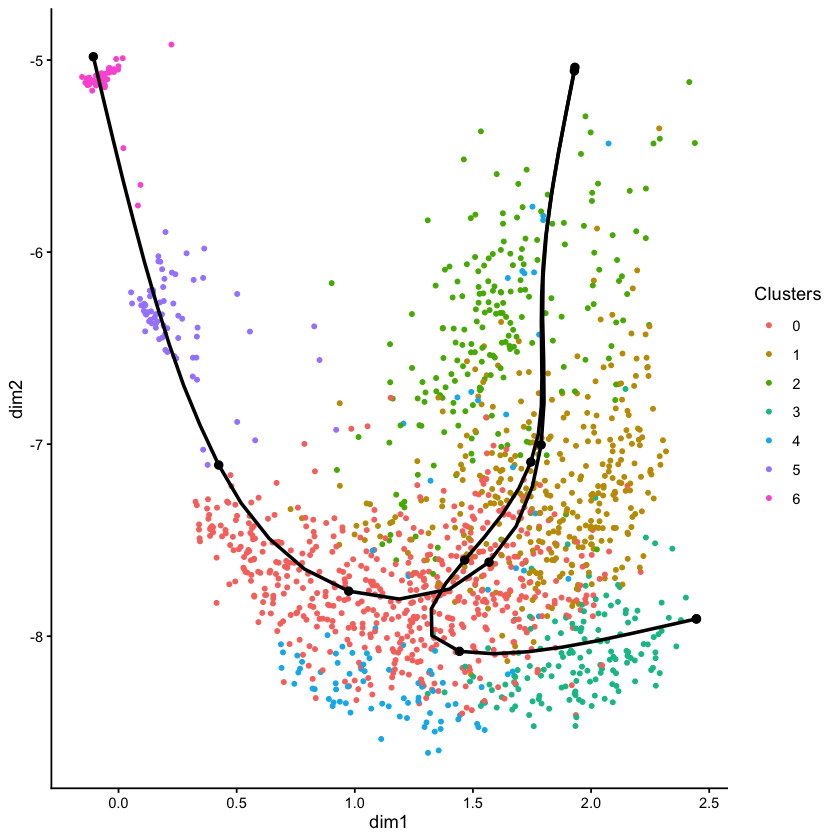

In [54]:
lineages <- getLineages(dimred, clustering, start.clus = '2')

curves <- getCurves(lineages, approx_points = 30, thresh = 0.01, stretch = 0.8, allow.breaks = FALSE, shrink = 0.99)

sce <- fitGAM(counts = as.matrix(counts), sds = curves)

startRes <- startVsEndTest(sce)

plotGeneCount(curves, counts, clusters = clustering, models = sce)

In [55]:
library(dplyr)
plot_differential_expression <- function(feature_id) {
    feature_id <- pseudotime_association %>% filter(pvalue < 0.05) %>% top_n(1, -waldStat) %>% pull(feature_id)
    cowplot::plot_grid(plotGeneCount(curves, counts, gene = feature_id[1], clusters = clustering, models = sce) + ggplot2::theme(legend.position = "none"), 
        plotSmoothers(sce, as.matrix(counts), gene = feature_id[1]))
    }

In [56]:
pseudotime_association <- associationTest(sce)
pseudotime_association$fdr <- p.adjust(pseudotime_association$pvalue, method = "fdr")
pseudotime_association <- pseudotime_association[order(pseudotime_association$pvalue), ]
pseudotime_association$feature_id <- rownames(pseudotime_association)

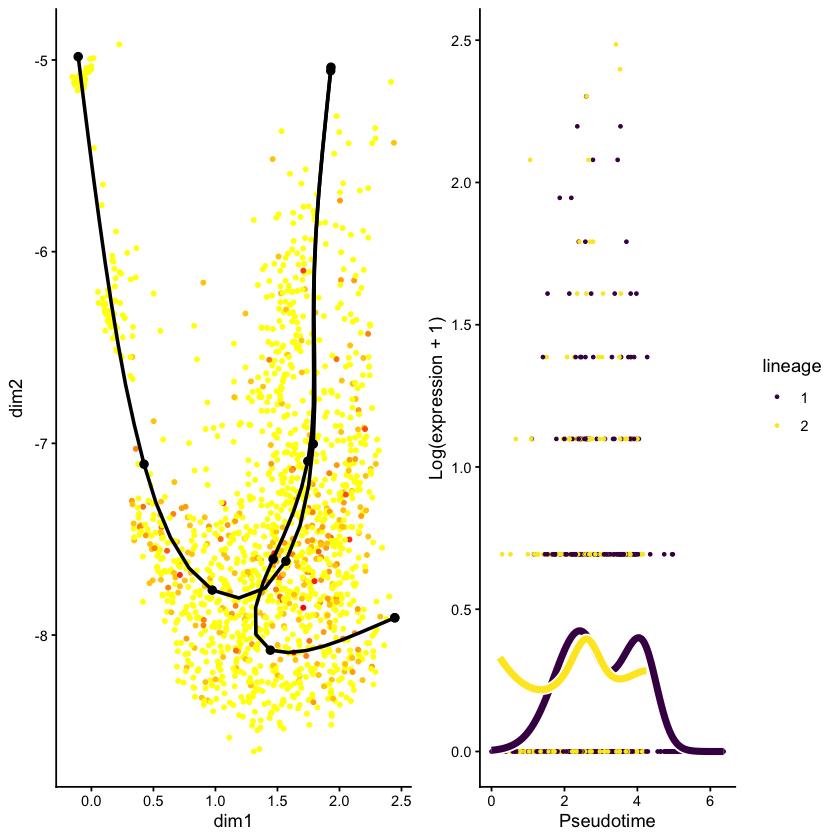

In [57]:
feature_id <- pseudotime_association %>% filter(pvalue < 0.05) %>% top_n(1, -waldStat) %>% pull(feature_id)
plot_differential_expression(feature_id)

In [58]:
different_end_association <- diffEndTest(sce)
different_end_association$feature_id <- rownames(different_end_association)
feature_id <- different_end_association %>% filter(pvalue < 0.05) %>% arrange(desc(waldStat)) %>% dplyr::slice(1) %>% pull(feature_id)

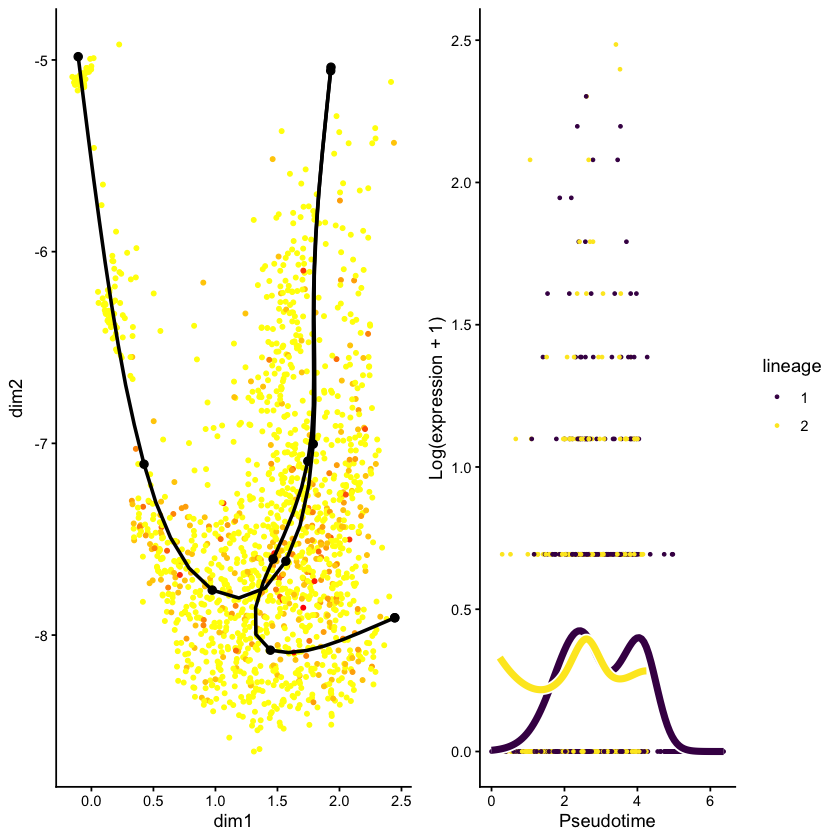

In [59]:
plot_differential_expression(feature_id)

In [60]:
startRes

,waldStat,df,pvalue,logFClineage1,logFClineage2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ANXA5,2.5604314,2,2.779773e-01,-0.843809374,0.44638061
AQP9,11.9145980,2,2.586890e-03,-6.759606018,1.56365993
ARL4C,2.2425544,2,3.258633e-01,29.482496001,0.68323495
BCL2A1,25.9288194,2,2.342224e-06,-3.400390514,0.84291383
C10orf54,6.6087055,2,3.672297e-02,0.713147974,2.84124344
CCL20,3.2484777,2,1.970616e-01,-2.174351942,1.07664038
CCL3,28.4102961,2,6.773023e-07,-13.567497151,0.47325461
CCL4,10.2047730,2,6.082214e-03,-51.534436001,-0.72538050
CD14,5.7792207,2,5.559787e-02,-2.673084022,2.95845511


In [63]:
p <- plotGeneCount(curves, counts, gene = "FCN1") +
  plotGeneCount(curves, counts, gene = "S100A9") +
  plotGeneCount(curves, counts, gene = "S100A12") +
  plotGeneCount(curves, counts, gene = "IL1B") +
  plotGeneCount(curves, counts, gene = "CCL3") +
  plotGeneCount(curves, counts, gene = "CXCL1") +
  plotGeneCount(curves, counts, gene = "ITGAX") +
  plotGeneCount(curves, counts, gene = "HLA-DRA") +
  plotGeneCount(curves, counts, gene = "CD74") +
  plotGeneCount(curves, counts, gene = "FCER1G") +
  plotGeneCount(curves, counts, gene = "LY86") +
  plotGeneCount(curves, counts, gene = "ICAM1")

ggsave(
  filename = "Mono_DC_lineage_genes_600dpi.jpg",
  plot = p,
  width = 30,
  height = 16,
  units = "in",
  dpi = 600,
  device = "jpeg",
  quality = 100
)

In [65]:
p <- plotGeneCount(curves, counts, clusters = clustering, models = sce)

ggsave(
  filename = "Curves.jpg",
  plot = p,
  width = 7,
  height = 6,
  units = "in",
  dpi = 600,
  device = "jpeg",
  quality = 100
)

In [ ]:
saveRDS(obj, file = "MonoDCs.rds")